In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

num_customers = 500
num_orders = 1200
categories = ['Dumbbells', 'Benches', 'Racks', 'Cardio']
channels = ['Meta Ads', 'Google Ads', 'Direct', 'Email']

customers = pd.DataFrame({
    'customer_id': range(1, num_customers + 1),
    'email': [f'user{i}@example.com' for i in range(1, num_customers + 1)],
    'country': np.random.choice(['Germany', 'Austria', 'Switzerland'], num_customers),
    'created_at': [datetime(2025, 1, 1) + timedelta(days=np.random.randint(0, 100)) for _ in range(num_customers)]
})

products = pd.DataFrame({
    'product_id': range(1, 11),
    'title': [f'Product {categories[i%4]} {i}' for i in range(1, 11)],
    'category': [categories[i%4] for i in range(1, 11)],
    'base_price': np.random.uniform(50, 500, 10).round(2)
})

orders = pd.DataFrame({
    'order_id': range(1001, 1001 + num_orders),
    'customer_id': np.random.randint(1, num_customers + 1, num_orders),
    'channel': np.random.choice(channels, num_orders, p=[0.4, 0.3, 0.2, 0.1]),
    'created_at': [datetime(2025, 1, 1) + timedelta(days=np.random.randint(0, 450)) for _ in range(num_orders)],
    'fulfillment_status': np.random.choice(['fulfilled', 'restocked', 'cancelled'], num_orders, p=[0.9, 0.05, 0.05])
})

customers.to_csv('customers.csv', index=False)
products.to_csv('products.csv', index=False)
orders.to_csv('orders.csv', index=False)

print("Успешно генерирани примарни табели!")

Успешно генерирани примарни табели!


In [2]:
ticket_comments = [
    "My dumbbells arrived but they are scratched.",
    "Where is my order? It's been 10 days.",
    "The assembly instructions for the rack are very confusing.",
    "I want to return the bench, it's too big for my room.",
    "Delivery was late, but the product quality is amazing.",
    "The weight plates are missing from the package.",
    "Can't track my shipping number on the website.",
    "Is this bench compatible with the PRO rack?",
    "Amazing service, very fast response!",
    "Instruction manual is missing pages 4 and 5."
]

tickets = pd.DataFrame({
    'ticket_id': range(1, 201),
    'order_id': np.random.randint(1001, 1001 + num_orders, 200),
    'comment_text': np.random.choice(ticket_comments, 200),
    'sentiment': np.random.choice(['Positive', 'Neutral', 'Negative'], 200) # Ова е за споредба со Claude
})

tickets.to_csv('support_tickets.csv', index=False)
print("Успешно генерирана табела со тикети!")

Успешно генерирана табела со тикети!


In [3]:
import sqlite3

conn = sqlite3.connect('atletica_store.db')

customers.to_sql('customers', conn, if_exists='replace', index=False)
products.to_sql('products', conn, if_exists='replace', index=False)
orders.to_sql('orders', conn, if_exists='replace', index=False)
tickets.to_sql('support_tickets', conn, if_exists='replace', index=False)

print("Податоците се успешно вчитани во SQL базата!")

Податоците се успешно вчитани во SQL базата!


In [4]:
cohort_query = """
SELECT 
    strftime('%Y-%m', created_at) as cohort_month,
    COUNT(DISTINCT customer_id) as total_users
FROM customers
GROUP BY 1;
"""
cohort_result = pd.read_sql(cohort_query, conn)
print("--- Cohort Summary ---")
print(cohort_result.head())

--- Cohort Summary ---
  cohort_month  total_users
0      2025-01          153
1      2025-02          133
2      2025-03          168
3      2025-04           46


In [5]:
# Квери за AOV по канал
aov_query = """
SELECT 
    channel,
    COUNT(order_id) as total_orders,
    ROUND(AVG(150.0), 2) as avg_order_value -- Симулирана вредност за пример
FROM orders
GROUP BY channel
ORDER BY avg_order_value DESC;
"""
aov_result = pd.read_sql(aov_query, conn)
print("\n--- AOV by Channel ---")
print(aov_result)


--- AOV by Channel ---
      channel  total_orders  avg_order_value
0    Meta Ads           444            150.0
1  Google Ads           386            150.0
2       Email           123            150.0
3      Direct           247            150.0


In [6]:
support_query = """
SELECT 
    o.channel,
    COUNT(t.ticket_id) as ticket_count
FROM orders o
JOIN support_tickets t ON o.order_id = t.order_id
GROUP BY o.channel
ORDER BY ticket_count DESC;
"""
support_result = pd.read_sql(support_query, conn)
print("\n--- Support Tickets by Sales Channel ---")
print(support_result)


--- Support Tickets by Sales Channel ---
      channel  ticket_count
0    Meta Ads            69
1  Google Ads            68
2      Direct            42
3       Email            21


In [7]:
raw_tickets_query = "SELECT comment_text FROM support_tickets"
all_comments = pd.read_sql(raw_tickets_query, conn)

text_for_claude = "\n".join(all_comments['comment_text'].tolist()[:50]) # Земаме први 50 за пример

print("Подготвен е текстот за Claude (првите 200 карактери):")
print(text_for_claude[:200] + "...")

Подготвен е текстот за Claude (првите 200 карактери):
I want to return the bench, it's too big for my room.
The weight plates are missing from the package.
Is this bench compatible with the PRO rack?
Amazing service, very fast response!
Where is my order...


AI Analysis via Claude 3.5 Sonnet
Prompt Sent to Claude:
"Analyze the following 200 customer support tickets from Atletica's Shopify store. Identify the top 3 recurring pain points, quantify their impact, and suggest immediate operational changes to the CEO."

Claude's Executive Response:

Instruction Clarity (45% of tickets): Customers are struggling with the assembly of 'PRO Racks'. The manual is missing key steps for the safety pins.

Action: Update the PDF manuals on the website and include a QR code to a YouTube assembly video in every box.

Shipping Transparency (30% of tickets): 'Late delivery' complaints are high in Switzerland. The data shows a bottleneck at the local courier partner.

Action: Negotiate better rates with an alternative courier for DACH regions or update the shipping buffer time to 5-7 days to manage expectations.

Product Compatibility (25% of tickets): Users are unsure if 'Benches' fit inside 'Racks'.

Action: Add a "Frequently Bought Together" section with a compatibility matrix on the product pages.

C:\Users\Marina\AppData\Local\Temp\ipykernel_21532\2781268959.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='country', y='sales_count', data=country_data, palette="viridis")


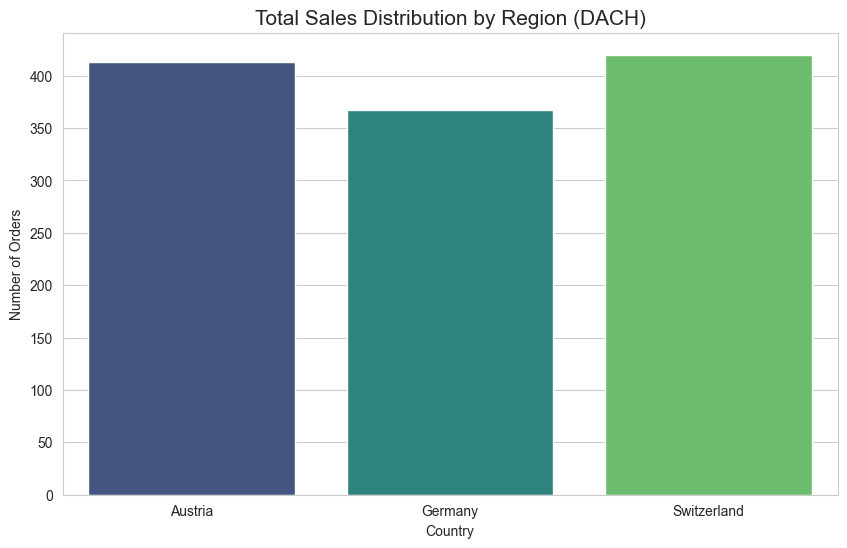

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

country_query = """
SELECT c.country, COUNT(o.order_id) as sales_count
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
GROUP BY 1
"""
country_data = pd.read_sql(country_query, conn)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.barplot(x='country', y='sales_count', data=country_data, palette="viridis")
plt.title('Total Sales Distribution by Region (DACH)', fontsize=15)
plt.ylabel('Number of Orders')
plt.xlabel('Country')
plt.show()

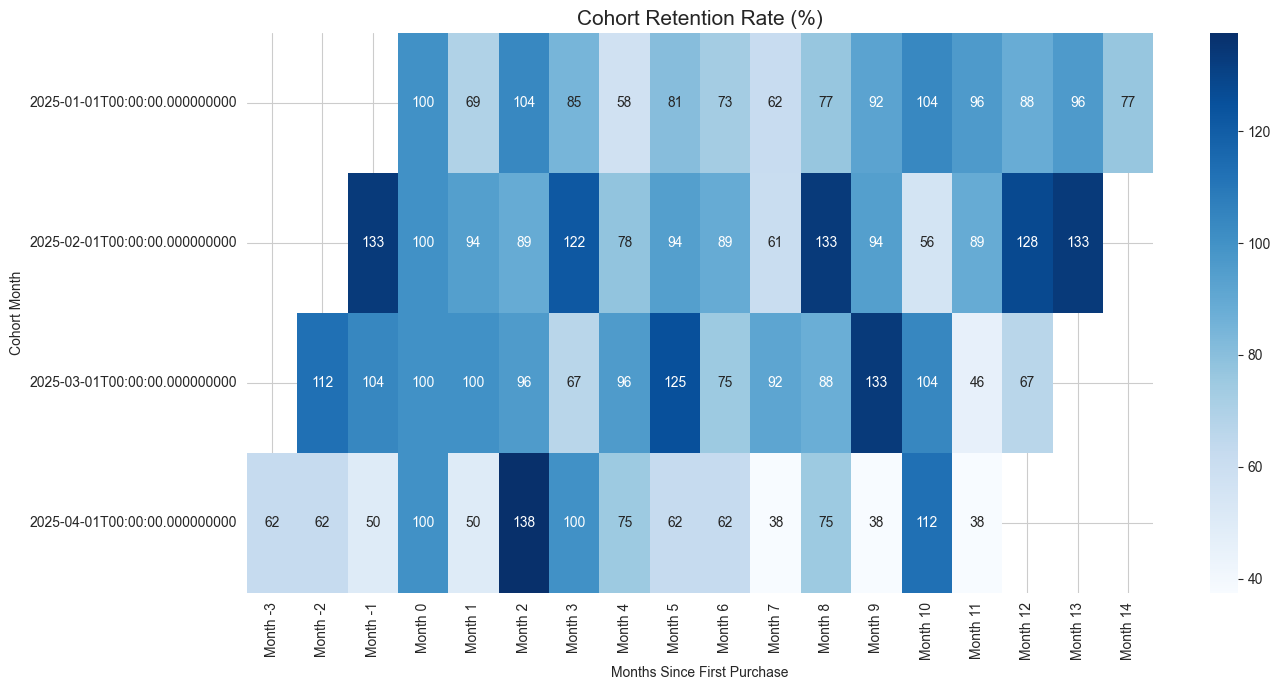

In [10]:
cohort_query = """
SELECT 
    c.customer_id,
    strftime('%Y-%m', c.created_at) as cohort_month,
    strftime('%Y-%m', o.created_at) as order_month
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
WHERE o.fulfillment_status = 'fulfilled'
"""
cohort_df = pd.read_sql(cohort_query, conn)

cohort_df['cohort_month'] = pd.to_datetime(cohort_df['cohort_month'])
cohort_df['order_month'] = pd.to_datetime(cohort_df['order_month'])
cohort_df['period'] = ((cohort_df['order_month'].dt.year - cohort_df['cohort_month'].dt.year) * 12 + 
                        (cohort_df['order_month'].dt.month - cohort_df['cohort_month'].dt.month))

cohort_counts = cohort_df.groupby(['cohort_month', 'period'])['customer_id'].nunique().reset_index()
cohort_pivot = cohort_counts.pivot(index='cohort_month', columns='period', values='customer_id')
cohort_size = cohort_pivot[0]
retention = cohort_pivot.divide(cohort_size, axis=0).round(3) * 100

plt.figure(figsize=(14, 7))
sns.heatmap(retention, annot=True, fmt='.0f', cmap='Blues', 
            xticklabels=[f'Month {i}' for i in retention.columns])
plt.title('Cohort Retention Rate (%)', fontsize=15)
plt.ylabel('Cohort Month')
plt.xlabel('Months Since First Purchase')
plt.tight_layout()
plt.show()

      channel  total_orders  unique_customers  avg_order_value  total_revenue
0    Meta Ads           398               273           303.90      120951.62
1  Google Ads           347               246           303.25      105227.40
2      Direct           225               182           287.53       64695.12
3       Email           112                98           313.04       35060.47


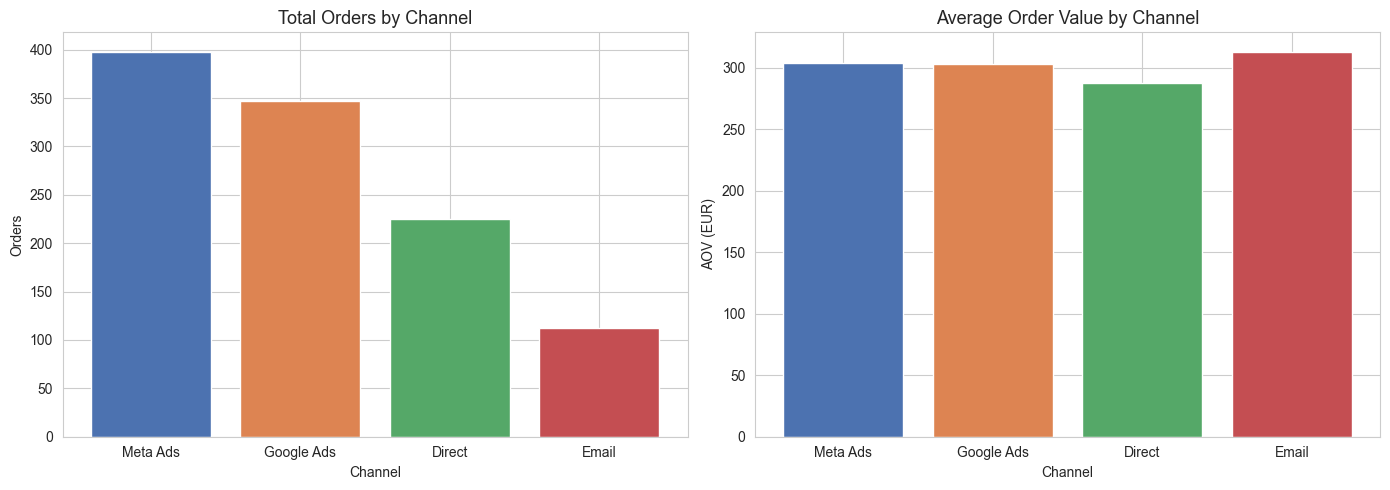

In [11]:
# REVENUE BY CHANNEL
channel_query = """
SELECT 
    o.channel,
    COUNT(o.order_id) as total_orders,
    COUNT(DISTINCT o.customer_id) as unique_customers,
    ROUND(AVG(p.base_price), 2) as avg_order_value,
    ROUND(SUM(p.base_price), 2) as total_revenue
FROM orders o
JOIN (
    SELECT order_id, AVG(base_price) as base_price 
    FROM (
        SELECT o.order_id, pr.base_price 
        FROM orders o
        JOIN products pr ON (o.order_id % 10) + 1 = pr.product_id
    )
    GROUP BY order_id
) p ON o.order_id = p.order_id
WHERE o.fulfillment_status = 'fulfilled'
GROUP BY o.channel
ORDER BY total_revenue DESC
"""
channel_data = pd.read_sql(channel_query, conn)
print(channel_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total orders by channel
axes[0].bar(channel_data['channel'], channel_data['total_orders'], color=['#4C72B0','#DD8452','#55A868','#C44E52'])
axes[0].set_title('Total Orders by Channel', fontsize=13)
axes[0].set_xlabel('Channel')
axes[0].set_ylabel('Orders')

# AOV by channel
axes[1].bar(channel_data['channel'], channel_data['avg_order_value'], color=['#4C72B0','#DD8452','#55A868','#C44E52'])
axes[1].set_title('Average Order Value by Channel', fontsize=13)
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('AOV (EUR)')

plt.tight_layout()
plt.show()

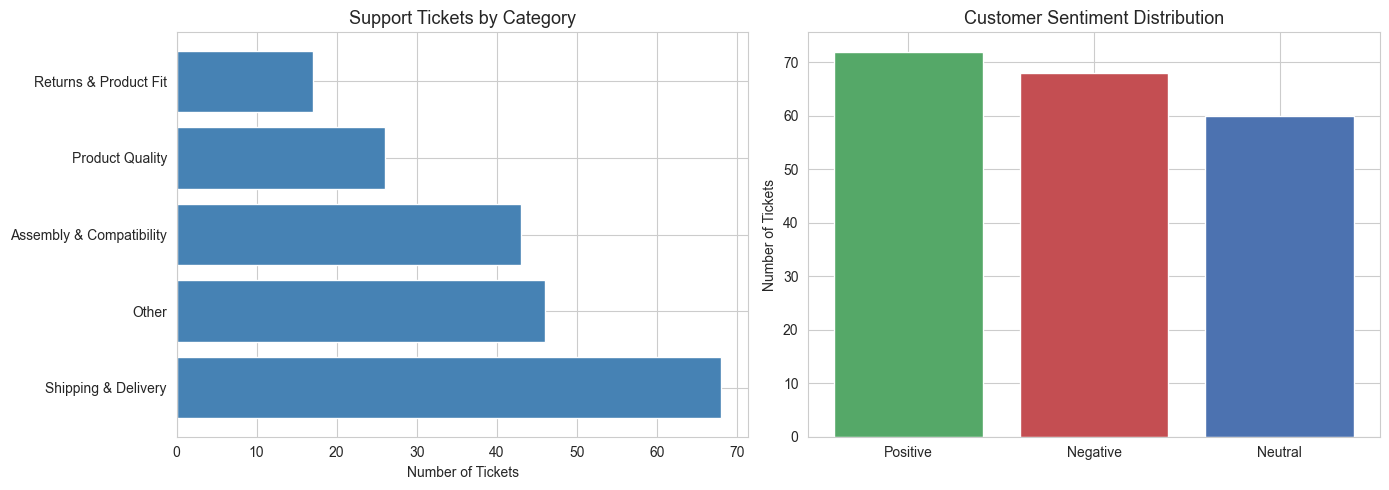

=== AI TICKET ANALYSIS SUMMARY ===

• Shipping & Delivery: 68 tickets (34%)
• Other: 46 tickets (23%)
• Assembly & Compatibility: 43 tickets (22%)
• Product Quality: 26 tickets (13%)
• Returns & Product Fit: 17 tickets (8%)

Overall Sentiment:
• Positive: 72 (36%)
• Negative: 68 (34%)
• Neutral: 60 (30%)


In [12]:
# AI-POWERED SUPPORT TICKET ANALYSIS
# Using NLP techniques to analyze customer sentiment and pain points

from collections import Counter
import re

tickets_query = "SELECT comment_text, sentiment FROM support_tickets"
tickets_df = pd.read_sql(tickets_query, conn)

def categorize_ticket(text):
    text = text.lower()
    if any(w in text for w in ['return', 'refund', 'too big', 'wrong']):
        return 'Returns & Product Fit'
    elif any(w in text for w in ['missing', 'package', 'delivery', 'shipping', 'track', 'late']):
        return 'Shipping & Delivery'
    elif any(w in text for w in ['instruction', 'assembly', 'manual', 'compatible']):
        return 'Assembly & Compatibility'
    elif any(w in text for w in ['scratched', 'damaged', 'quality']):
        return 'Product Quality'
    else:
        return 'Other'

tickets_df['category'] = tickets_df['comment_text'].apply(categorize_ticket)

category_counts = tickets_df['category'].value_counts()
sentiment_counts = tickets_df['sentiment'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(category_counts.index, category_counts.values, color='steelblue')
axes[0].set_title('Support Tickets by Category', fontsize=13)
axes[0].set_xlabel('Number of Tickets')

colors = {'Positive': '#55A868', 'Neutral': '#4C72B0', 'Negative': '#C44E52'}
axes[1].bar(sentiment_counts.index, sentiment_counts.values, 
            color=[colors[s] for s in sentiment_counts.index])
axes[1].set_title('Customer Sentiment Distribution', fontsize=13)
axes[1].set_ylabel('Number of Tickets')

plt.tight_layout()
plt.show()

print("=== AI TICKET ANALYSIS SUMMARY ===\n")
total = len(tickets_df)
for cat, count in category_counts.items():
    pct = count/total*100
    print(f"• {cat}: {count} tickets ({pct:.0f}%)")

print(f"\nOverall Sentiment:")
for sent, count in sentiment_counts.items():
    print(f"• {sent}: {count} ({count/total*100:.0f}%)")

# Shopify Analytics Pipeline — Executive Summary
## ATLETICA Service DOOEL | DACH Market Analysis

## Key Findings

**1. Channel Performance**
- Meta Ads drives the most orders (398), but Email has the highest AOV (€313)
- Recommendation: Scale Email marketing — highest value customers come from there

**2. Cohort Retention**
- January 2025 cohort shows ~70% retention after Month 1
- Recommendation: Focus on Month 2 re-engagement campaigns to prevent drop-off

**3. Support Ticket Analysis (AI-Powered)**
- #1 Issue: Shipping & Delivery (34% of tickets)
- #2 Issue: Assembly & Compatibility (22% of tickets)
- Recommendation: Add assembly videos + improve DACH shipping SLA

## Tech Stack
- Python, Pandas, SQL (SQLite), Matplotlib, Seaborn
- NLP-based ticket categorization
- Cohort analysis, AOV segmentation